## Project Background

Predictive maintenance has become a critical part of smart manufacturing, with industrial machines generating continuous streams of sensor data every day. However, not all machines operate under ideal conditions, some develop faults, some degrade unexpectedly, and some fail entirely with little warning. This problem is not only costly in terms of unplanned downtime and repair costs, but also disrupts production schedules and puts pressure on maintenance teams.

This dataset **Smart Manufacturing IoT-Cloud Monitoring Dataset** is the publicly available, sourced from Kaggle. Ultimately, this project focuses on building a predictive model that classifies whether a machine requires maintenance, using real-time sensor readings such as Temperature, Vibration, Humidity, Pressure, and Energy Consumption to detect early signs of mechanical stress or failure before they escalate into full breakdowns.

---

## Business Problem

Machine failures in industrial settings are unpredictable and negatively impact multiple stakeholders:

### For Organizations
- **Operational costs increase:** Unplanned downtime, emergency repairs, and lost production output drive up costs significantly compared to scheduled maintenance.
- **Production disruptions:** A single machine failure on a production line can cascade, delaying downstream processes and affecting overall output targets.

### For Maintenance & Operations Teams
- **Increased reactive workload:** Without early warning, teams are forced into constant work rather than planned, efficient maintenance scheduling.
- **Resource strain:** Technicians, spare parts inventory, and diagnostic equipment are all pushed to capacity when multiple machines fail around the same time.

### For End-Users / Downstream Stakeholders
- **Delivery delays:** Production slowdowns or halts can result in missed deadlines for goods or components relying on the affected machinery.
- **Safety and trust concerns:** Undetected mechanical failures (e.g. overheating, excessive vibration) can pose safety risks to workers and erode confidence in the reliability of the manufacturing process.

---

## Business Objective
The primary objective of this project is to develop a few machine learning models that predicts whether a machine requires maintenance based on real-time sensor readings.<br>The objectives are:<br>
1. To identify and analyse the key factors that indicate a machine is at risk, such as Temperature, Vibration, and Energy Consumption.
2. To build and compare multiple classification models in order to determine which model performs best.
3. To evaluate model performance using appropriate metrics such as Accuracy, Precision, Recall, F1-score.
4. To generate meaningful insights based on the entire experience of training the model (improvements for future iterations).

# 1.0 Import Libraries & Data

In [1]:
import pandas as pd
from extra.utils import load_config
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
cfg = load_config()

Config loaded successfully!

data:
  raw_path: ../data/raw/smart_manufacturing_data.csv
  interim_path: ../data/interim/cleaned.csv
  processed_path: ../data/processed/features.csv
  target_column: maintenance_required
cleaning: null
features:
  rolling_window_size: 5
  sensor_columns:
  - temperature
  - vibration
  - humidity
  - pressure
  - energy_consumption
  - predicted_remaining_life
model:
  n_jobs: 2
  session_id: 42
  train_size: 0.8
  ignore_features:
  - failure_type
  - downtime_risk
  - anomaly_flag
  - machine_status
mlflow:
  tracking_uri: http://127.0.0.1:5000
  experiment_name: Smart Manufacturing Maintenance



In [3]:
df = pd.read_csv(cfg.data.raw_path)

# 2.0 Statistical Exploratory Data Analysis (EDA)
In this section, I will dive into the dataset and perform standard statistical analysis to explore and find out the underlying structure, quality, and characteristics of the data before any cleaning or feature engineering takes place. This includes examining the shape and data types of each column, checking for missing values and duplicates, reviewing summary statistics (mean, median, standard deviation, min/max) for numerical sensor readings, and understanding the distribution of categorical variables such as Machine_Status and Failure_Type. The goal of this stage is purely descriptive, understanding what the data actually looks like and laying the groundwork for the cleaning steps that follows in the next notebook.

In [4]:
df.head()

,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-01 00:00:00,39,78.61,28.65,79.96,3.73,2.16,1,0,106,Normal,0.0,0
1,2025-01-01 00:01:00,29,68.19,57.28,35.94,3.64,0.69,1,0,320,Normal,0.0,0
2,2025-01-01 00:02:00,15,98.94,50.20,72.06,1.00,2.49,1,1,19,Normal,1.0,1
3,2025-01-01 00:03:00,43,90.91,37.65,30.34,3.15,4.96,1,1,10,Normal,1.0,1
4,2025-01-01 00:04:00,8,72.32,40.69,56.71,2.68,0.63,2,0,65,Vibration Issue,0.0,1


In [5]:
df.shape

(100000, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   timestamp                 100000 non-null  object 
 1   machine_id                100000 non-null  int64  
 2   temperature               100000 non-null  float64
 3   vibration                 100000 non-null  float64
 4   humidity                  100000 non-null  float64
 5   pressure                  100000 non-null  float64
 6   energy_consumption        100000 non-null  float64
 7   machine_status            100000 non-null  int64  
 8   anomaly_flag              100000 non-null  int64  
 9   predicted_remaining_life  100000 non-null  int64  
 10  failure_type              100000 non-null  object 
 11  downtime_risk             100000 non-null  float64
 12  maintenance_required      100000 non-null  int64  
dtypes: float64(6), int64(5), object(2)
memory usa

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
machine_id,100000.0,25.499330,14.389439,1.00,13.0000,25.00,38.00,50.00
temperature,100000.0,75.015625,10.031884,35.55,68.2675,75.06,81.75,121.94
vibration,100000.0,50.012270,14.985444,-17.09,39.9700,49.96,60.10,113.80
humidity,100000.0,54.995401,14.437960,30.00,42.5200,54.98,67.50,80.00
pressure,100000.0,3.000405,1.152399,1.00,2.0000,3.01,4.00,5.00
energy_consumption,100000.0,2.747064,1.297865,0.50,1.6300,2.74,3.87,5.00
machine_status,100000.0,1.002050,0.446193,0.00,1.0000,1.00,1.00,2.00
anomaly_flag,100000.0,0.089160,0.284976,0.00,0.0000,0.00,0.00,1.00
predicted_remaining_life,100000.0,234.269160,150.063062,1.00,97.0000,230.00,365.00,499.00
downtime_risk,100000.0,0.089155,0.284961,0.00,0.0000,0.00,0.00,1.00


^^ Here we see that the vibration is negative, I will do some checks in the cleaning step before I do anything.

With **100,000 rows** and **13 columns**, this dataset provides a solid foundation for building a reliable classification model. Here are some supporting arguments:

- **Sample size**: 100,000 records is comfortably large for tabular classification tasks well beyond the typical minimum needed for tree-based ensemble models (Random Forest, XGBoost, LightGBM) to learn stable patterns, and large enough to support a proper train/test split (and cross-validation folds within training) without either subset becoming too small to be representative.

- **Class distribution**: While the target variable (`maintenance_required`) is imbalanced, the minority class still contains like 20k records which is enough for the model to learn meaningful patterns from, especially when paired with appropriate handling (e.g. class weighting, or evaluating with Precision/Recall/F1 rather than relying on Accuracy alone).

- **Feature richness**: With 5 continuous sensor readings (Temperature, Vibration, Humidity, Pressure, Energy Consumption), there is enough variety in the feature space for me to do feature engineering for eg: rolling statistics, etc, beyond just the raw sensor values alone.

In [8]:
print(df.isnull().sum())
print("\n")
print(df.duplicated().sum())

timestamp                   0
machine_id                  0
temperature                 0
vibration                   0
humidity                    0
pressure                    0
energy_consumption          0
machine_status              0
anomaly_flag                0
predicted_remaining_life    0
failure_type                0
downtime_risk               0
maintenance_required        0
dtype: int64


0


# 2.1 Additional Data Quality Checks
This section is shorter as such I will just leave comments within the cell rather than create a whole markdown block.<br> Here I will write down my intent and the insight I derived from my analysis.

In [9]:
# Check for any columns with only 1 unique value aka useless columns
# Insight: There are no useless columns in my dataset
df.nunique().sort_values()

anomaly_flag                     2
maintenance_required             2
machine_status                   3
failure_type                     5
downtime_risk                    9
machine_id                      50
pressure                       401
energy_consumption             451
predicted_remaining_life       499
humidity                      5001
temperature                   5827
vibration                     8221
timestamp                   100000
dtype: int64

In [10]:
# Check for dataset imbalance
# Insight: Might need to use weighted models when training because of the 80/20 class imbalance
df['maintenance_required'].value_counts(normalize=True)

maintenance_required
0    0.80303
1    0.19697
Name: proportion, dtype: float64

In [11]:
# Check coefficient of variation (see if values are spread out)
# Insight: All the values showed meaningful variability so they can all be kept in the model training process
numeric_cols = ['temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption', 'predicted_remaining_life', 'machine_status']
df[numeric_cols].std() / df[numeric_cols].mean()

temperature                 0.133731
vibration                   0.299635
humidity                    0.262530
pressure                    0.384081
energy_consumption          0.472455
predicted_remaining_life    0.640558
machine_status              0.445280
dtype: float64

## 2.2 Correlation Analysis
In this section, I did pearson correlation analysis and independent t-test to find linear correlation and segmented analysis between the dataset and the target label. This has to be done because I need to prove that I can work on this dataset rather than simply passing the data over to a model and praying that it works.

In a real MLOps lifecycle, this is effectively a **go/no-go checkpoint** for the entire project. If the data showed no meaningful relationship between the available features and the target variable, continuing forward into cleaning, feature engineering, and model training would be a waste of time and compute resources, no amount of hyperparameter tuning or algorithm selection can compensate for a dataset that simply doesn't contain the signal needed to predict the outcome. Validating this upfront is what separates a properly grounded ML project from one built on blind trial-and-error.


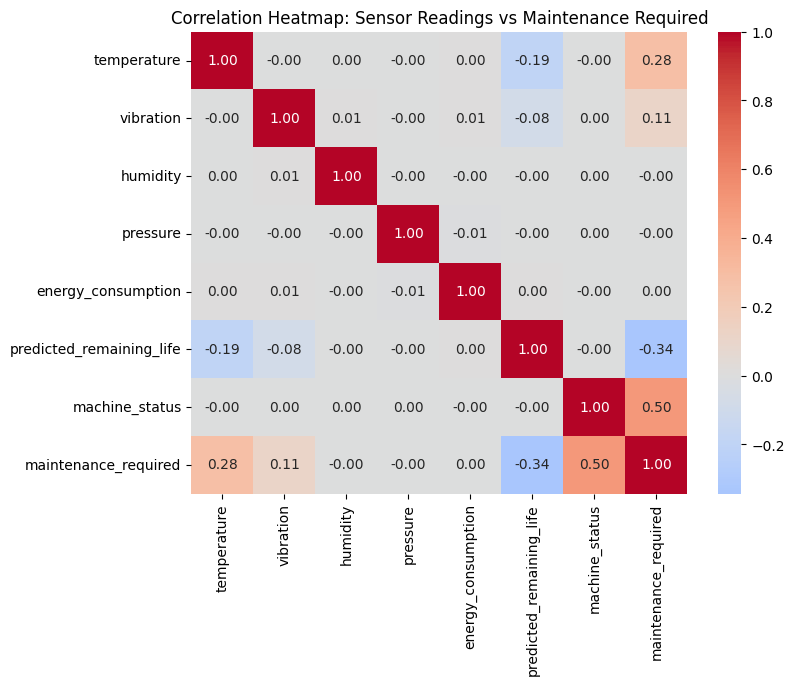

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[numeric_cols + ['maintenance_required']].corr(),
    annot=True, fmt='.2f', cmap='coolwarm', center=0
)
plt.title('Correlation Heatmap: Sensor Readings vs Maintenance Required')
plt.show()

In [13]:
# Compare average sensor readings: healthy machines vs machines needing maintenance
df.groupby('maintenance_required')[numeric_cols].mean()

# Check if each sensor's difference between the two groups is "real" or just random chance
# (p-value < 0.05 = the difference is unlikely to be a coincidence)
for col in numeric_cols:
    healthy = df[df['maintenance_required']==0][col]
    needs_maint = df[df['maintenance_required']==1][col]
    t_stat, p_val = stats.ttest_ind(healthy, needs_maint)
    print(f"{col}: p-value = {p_val:.5f}")

temperature: p-value = 0.00000
vibration: p-value = 0.00000
humidity: p-value = 0.22770
pressure: p-value = 0.53848
energy_consumption: p-value = 0.66156
predicted_remaining_life: p-value = 0.00000
machine_status: p-value = 0.00000


On top of my earlier analysis on data quality, I also checked the Pearson correlation and t-test values to confirm the dataset actually contains meaningful predictive signal before moving forward. Here's why the dataset is fine for model training:

- **Statistical significance**: Hypothesis testing confirmed that Temperature, Vibration, Remaining Life and Machine Status show statistically significant differences between healthy and failing machines (p < 0.05), meaning these patterns are unlikely to have occurred by random chance.

- **Domain alignment**: These findings align with real-world industrial knowledge, overheating and excessive vibration are well-established, physically grounded indicators of mechanical failure, which adds confidence that the dataset reflects genuine, realistic patterns rather than arbitrary noise.

## 2.3 Dataset Efficiency
In this section, I check how the dataset's columns are currently stored by reviewing each column's data type and memory usage. This involves inspecting `df.dtypes` to see how each column is represented, and using `df.memory_usage(deep=True)` to measure how much memory each column actually uses. The goal is to spot columns that may be stored inefficiently and could benefit from conversion to a more suitable data type.

In [14]:
df.dtypes

timestamp                    object
machine_id                    int64
temperature                 float64
vibration                   float64
humidity                    float64
pressure                    float64
energy_consumption          float64
machine_status                int64
anomaly_flag                  int64
predicted_remaining_life      int64
failure_type                 object
downtime_risk               float64
maintenance_required          int64
dtype: object

In [15]:
df.memory_usage(deep=True)

Index                           128
timestamp                   7600000
machine_id                   800000
temperature                  800000
vibration                    800000
humidity                     800000
pressure                     800000
energy_consumption           800000
machine_status               800000
anomaly_flag                 800000
predicted_remaining_life     800000
failure_type                6362029
downtime_risk                800000
maintenance_required         800000
dtype: int64

In [16]:
df['failure_type'].value_counts()

failure_type
Normal              91899
Vibration Issue      3129
Overheating          1989
Pressure Drop        1969
Electrical Fault     1014
Name: count, dtype: int64

Looking at the data types and memory allocation, I identified a few columns that can be optimized:

**1. `timestamp` stored as an object (7.6M bytes)**

This is significantly more than the ~800KB (8 bytes per row) used by other columns of the same length. Since `timestamp` is currently stored as text rather than a proper datetime, it takes up unnecessary memory and prevents any date/time operations (e.g. extracting hour, day of week, etc.). This will be addressed in the cleaning step using pandas' `pd.to_datetime()` function.

**2. `failure_type` stored as an object (6.3M bytes)**

Since this column only contains a handful of repeated text values (e.g. `Normal`, `Vibration Issue`, `Overheating`), converting it to a `category` data type will reduce memory usage and make the dataset more efficient overall, without changing any of the underlying values.

# 2.4 Data Leakage

In [17]:
for col in ['failure_type', 'downtime_risk', 'anomaly_flag']:
    print(f"--- {col} vs maintenance_required ---")
    print(pd.crosstab(df[col], df['maintenance_required'], normalize='index'))
    print()

--- failure_type vs maintenance_required ---
maintenance_required         0         1
failure_type                            
Electrical Fault      0.000000  1.000000
Normal                0.873818  0.126182
Overheating           0.000000  1.000000
Pressure Drop         0.000000  1.000000
Vibration Issue       0.000000  1.000000

--- downtime_risk vs maintenance_required ---
maintenance_required         0         1
downtime_risk                           
0.00                  0.881637  0.118363
0.88                  0.000000  1.000000
0.92                  0.000000  1.000000
0.93                  0.000000  1.000000
0.94                  0.000000  1.000000
0.97                  0.000000  1.000000
0.98                  0.000000  1.000000
0.99                  0.000000  1.000000
1.00                  0.000000  1.000000

--- anomaly_flag vs maintenance_required ---
maintenance_required         0         1
anomaly_flag                            
0                     0.881637  0.118363
1

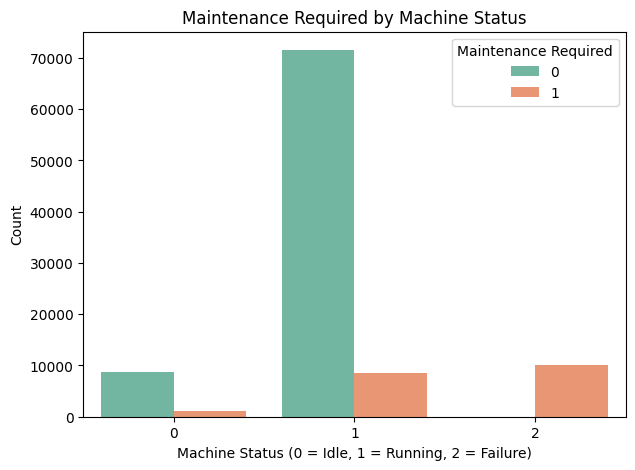

In [18]:
plt.figure(figsize=(7, 5))
sns.countplot(x='machine_status', hue='maintenance_required', data=df, palette='Set2')
plt.title('Maintenance Required by Machine Status')
plt.xlabel('Machine Status (0 = Idle, 1 = Running, 2 = Failure)')
plt.ylabel('Count')
plt.legend(title='Maintenance Required')
plt.show()

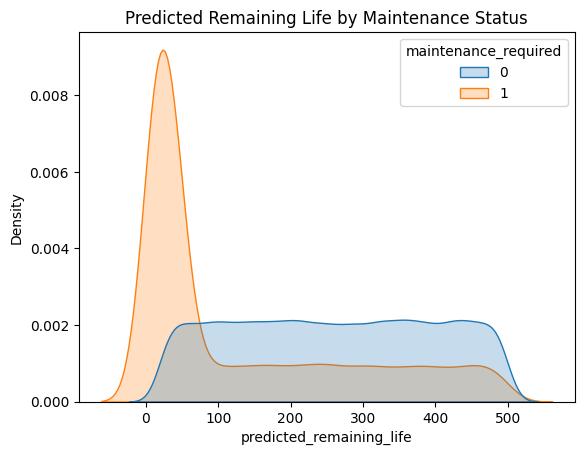

In [19]:
sns.kdeplot(data=df, x='predicted_remaining_life', hue='maintenance_required', fill=True, common_norm=False)
plt.title('Predicted Remaining Life by Maintenance Status')
plt.show()

### *Checking for Data Leakage*

To confirm suspicions raised earlier, I ran a crosstab comparing `predicted_remaining_life`, `machine_status`, `failure_type`, `downtime_risk`, and `anomaly_flag` against the target variable (`maintenance_required`). The results showed that whenever these columns indicated a perfect one-to-one relationship. This strongly suggests these columns are derived directly from the same underlying event as the target itself, rather than being independent predictive signals. Including them in the model would allow it to "cheat" by referencing this pre-computed information instead of learning genuine patterns from the sensor data. As such, `predicted_remaining_life`, `machine_status`, `failure_type`, `downtime_risk`, and `anomaly_flag` will be excluded from the feature set used for model training.

# 3.0 Storytelling Exploratory Data Analysis
In this section, I will use visualizations to uncover patterns, relationships, and anomalies within the data that aren't immediately obvious from summary statistics alone. Through graphs such as boxplots, correlation heatmaps, and time-based trend lines, I aim to understand how each sensor reading behaves in relation to the target variable (Maintenance_Required), identify potential problems and data quality issues that may need to be addressed during cleaning, and assess whether certain columns (such as Downtime_Risk_Score, Failure_Type, and Predicted_Remaining_Life) show signs of data leakage that would make them unsuitable as input features. The insights drawn from this section will directly inform the decisions made in the data cleaning and feature engineering stages that follow.

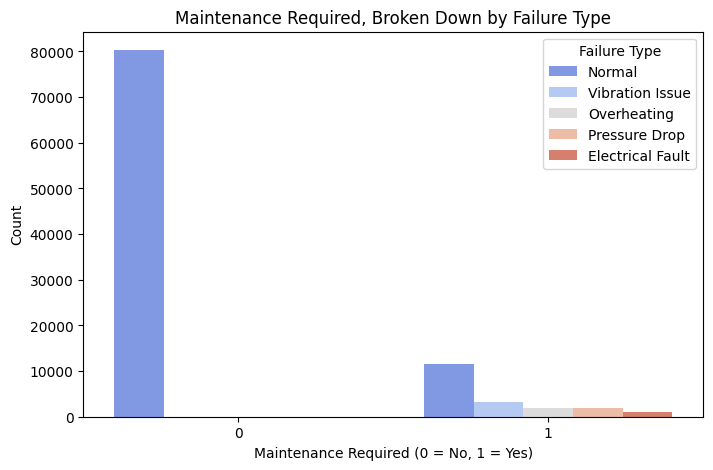

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(
    x='maintenance_required',
    hue='failure_type',
    data=df,
    palette='coolwarm'
)
plt.title('Maintenance Required, Broken Down by Failure Type')
plt.xlabel('Maintenance Required (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.legend(title='Failure Type')
plt.show()

This diagram shows that no all that require maintenance show obvious signs of failure as a huge chunk of those that need maintenance are considered as Normal. This could indicate a higher chance of False values (Positive or Negative) as the model might have a harder discerning whether a machine truly need maintenance. But we will see later on if the separation is obvious using PCA.

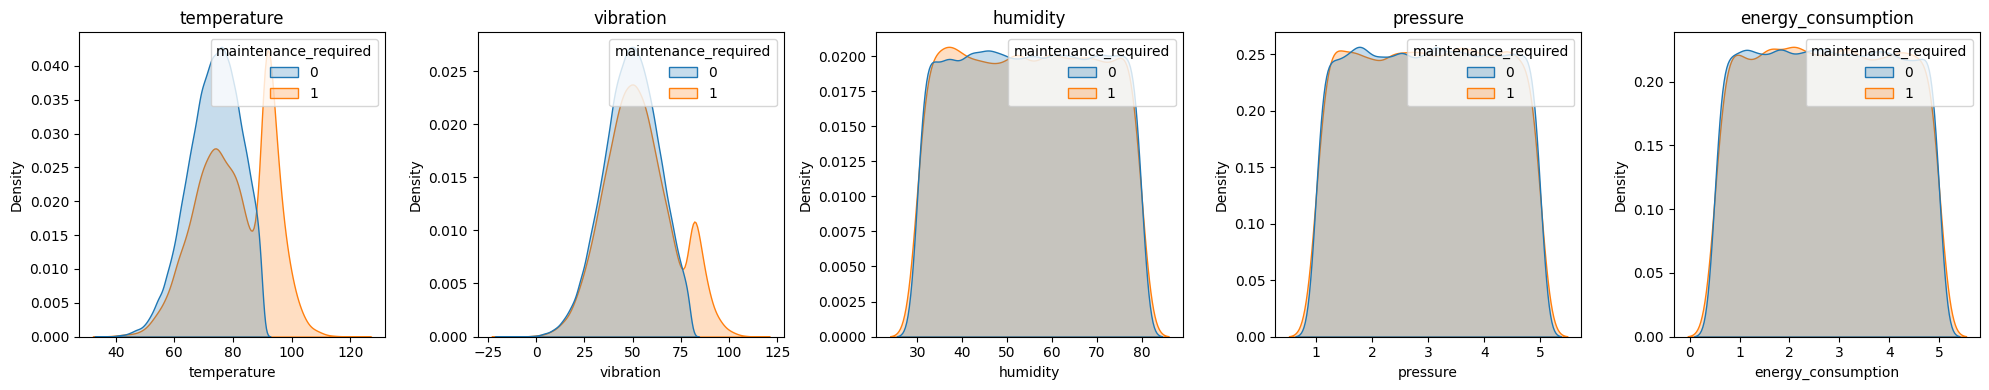

In [21]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, numeric_cols):
    sns.kdeplot(data=df, x=col, hue='maintenance_required', ax=ax, fill=True, common_norm=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Earlier I only understood that within the dataset there are signs that temperature, vibration, predicted machine life and machine status had correlation with higher chance of failure. But here we can clearly see where the separation begins and ends.<br>
<br>
Temperature: Healthy machines (blue) cluster mainly around 70-80°C, while machines needing maintenance (orange) shift noticeably higher, peaking around 90-100°C<br>
<br>
Vibration: Healthy machines peak around 50, while failing machines show a second smaller bump further right (~75–100), meaning a subset of failing machines show distinctly elevated vibration

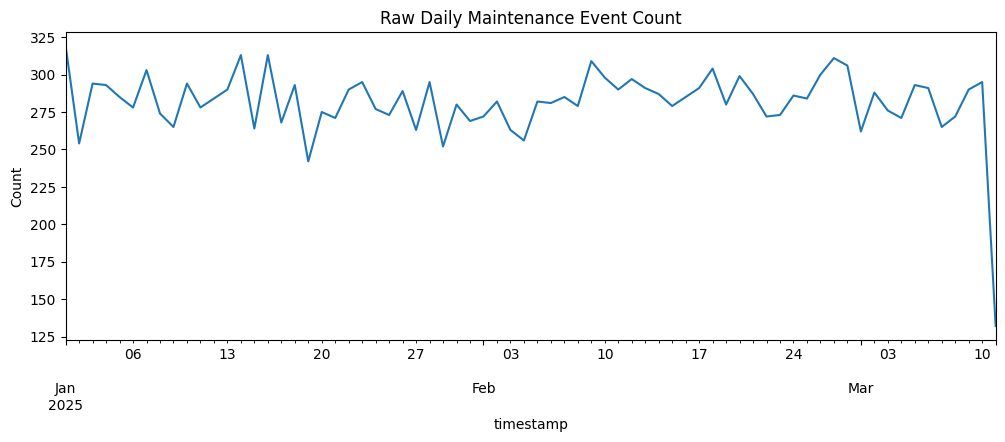

In [22]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
daily_count = df.set_index('timestamp')['maintenance_required'].resample('D').sum()
daily_count.plot(figsize=(12,4), title='Raw Daily Maintenance Event Count')
plt.ylabel('Count')
plt.show()

In [23]:
# How many readings actually exist on that last day?
df.set_index('timestamp').resample('D').size().tail(5)
# What's the very last timestamp in your entire dataset?
df['timestamp'].max()

Timestamp('2025-03-11 10:39:00')

The last day in the dataset (2025-03-11) contained only partial-day readings (data collection ended at 10:39 AM), resulting in an artificially low count when aggregated daily. This incomplete period was excluded from the time series analysis to avoid misrepresenting it as a genuine drop in maintenance activity.

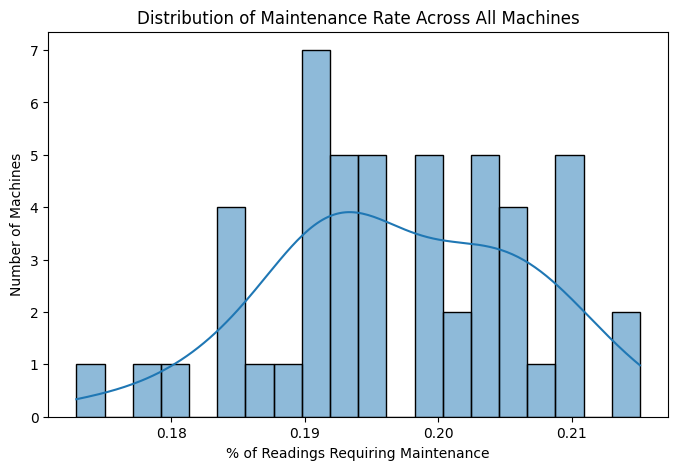

In [24]:
machine_risk_all = df.groupby('machine_id')['maintenance_required'].mean()

plt.figure(figsize=(8,5))
sns.histplot(machine_risk_all, bins=20, kde=True)
plt.title('Distribution of Maintenance Rate Across All Machines')
plt.xlabel('% of Readings Requiring Maintenance')
plt.ylabel('Number of Machines')
plt.show()

Machine ID might not play as big of a role in predicting machine maintenance due to this distribution. Its not super spread out where some machines have very high maintenance rates and some are super stable like in real life. However this is fine we can still add it into the model as the slight deviation might still have some pattern the model can train on.

<Figure size 1400x600 with 0 Axes>

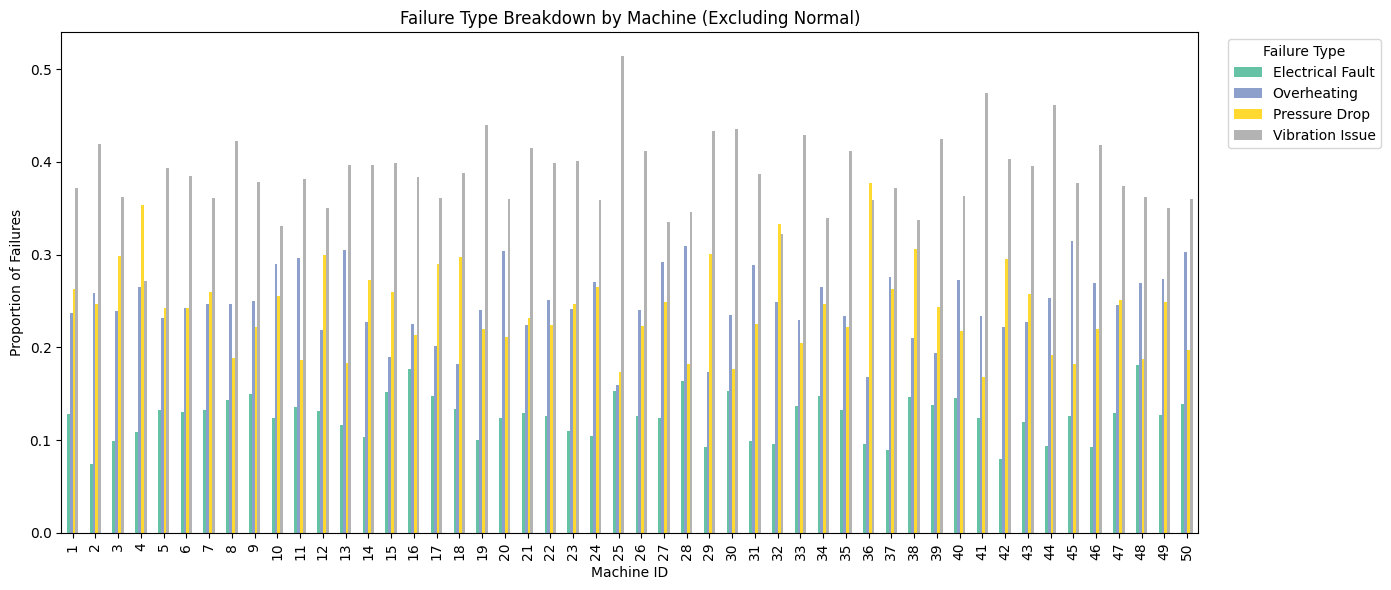

In [25]:
failure_only = df[df['failure_type'] != 'Normal']
machine_failure_dist_actual = pd.crosstab(failure_only['machine_id'], failure_only['failure_type'], normalize='index')
plt.figure(figsize=(14, 6))
machine_failure_dist_actual.plot(kind='bar', stacked=False, figsize=(14,6), colormap='Set2')
plt.title('Failure Type Breakdown by Machine (Excluding Normal)')
plt.xlabel('Machine ID')
plt.ylabel('Proportion of Failures')
plt.legend(title='Failure Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

The distribution of failure type shows that some machines do indeed have more failures than others. This can be useful when predicting failure type if I choose to pursue it later in the project.